<a href="https://colab.research.google.com/github/rahmanramish7/Car-Rental-System/blob/main/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
df=pd.read_csv("student_performance.csv")
import matplotlib.pyplot as plt


In [8]:
df

,hours_studied,attendance_rate,assignments_submitted,final_score
0,10,80,8,72
1,15,90,10,88
2,5,60,6,58
3,8,75,7,65
4,12,85,9,78
5,6,70,6,60
6,9,80,8,70
7,14,95,10,92
8,3,50,4,45
9,11,88,9,80


In [9]:
# Features and target
X = df[['hours_studied', 'attendance_rate', 'assignments_submitted']].values.astype(float)
y = df['final_score'].values.astype(float)

# Normalize features (mean=0, std=1) - important for gradient descent convergence
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_norm = (X - X_mean) / X_std


In [10]:

# Add bias term (column of ones) for intercept
X_norm = np.hstack((np.ones((X_norm.shape[0], 1)), X_norm))  # shape: (n_samples, n_features+1)

# Initialize weights (including intercept)
weights = np.zeros(X_norm.shape[1])  # m+1 weights (intercept + features)

# Hyperparameters
alpha = 0.01
iterations = 1000
n = len(y)

cost_history = []

# Gradient Descent loop
for i in range(iterations):
    y_pred = X_norm.dot(weights)  # predictions, shape (n,)
    error = y_pred - y            # error vector

    # Gradient calculation
    gradients = (1/n) * X_norm.T.dot(error)

    # Update weights
    weights = weights - alpha * gradients

    # Compute cost (MSE/2)
    cost = (1/(2*n)) * np.sum(error**2)
    cost_history.append(cost)

    if i % 100 == 0:
        print(f"Iteration {i}: Cost = {cost:.4f}")

print("\nFinal weights (intercept + coefficients):")
print(weights)

# Predict final scores
y_pred_final = X_norm.dot(weights)


Iteration 0: Cost = 2593.7750
Iteration 100: Cost = 332.5936
Iteration 200: Cost = 45.9640
Iteration 300: Cost = 7.5963
Iteration 400: Cost = 2.4495
Iteration 500: Cost = 1.7538
Iteration 600: Cost = 1.6547
Iteration 700: Cost = 1.6358
Iteration 800: Cost = 1.6278
Iteration 900: Cost = 1.6215

Final weights (intercept + coefficients):
[70.24696722  5.61959086  5.67571896  4.6426963 ]


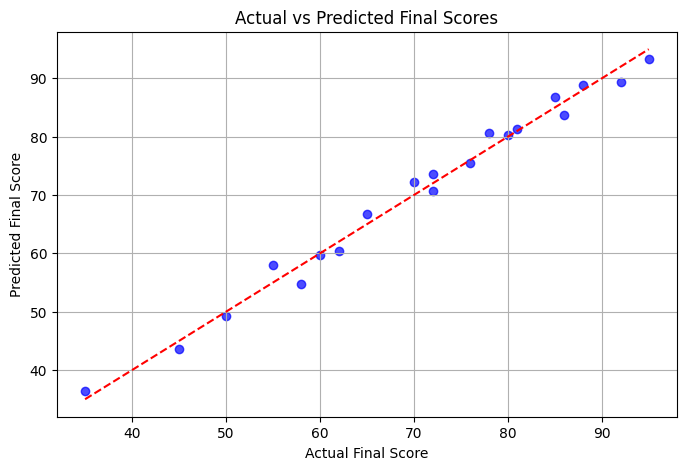

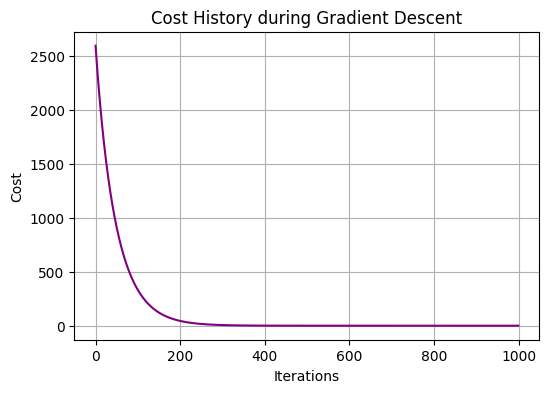

In [11]:

# Plot actual vs predicted final scores
plt.figure(figsize=(8,5))
plt.scatter(y, y_pred_final, color='blue', alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Actual vs Predicted Final Scores")
plt.grid(True)
plt.show()

# Plot cost history
plt.figure(figsize=(6,4))
plt.plot(cost_history, color='purple')
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost History during Gradient Descent")
plt.grid(True)
plt.show()